Using file: D:\C drive files\Downloads\Lab Session Data (1) (1).xlsx
Exists?   : True
------------------------------------------------------------
Dataset loaded: X = (2240, 24) | y = (2240,)
Feature names: ['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain']
------------------------------------------------------------
A1. Entropy of full dataset                : 0.6076
A1. Entropy after 4-bin equal-width binning: 0.0056
A2. Gini index of full dataset             : 0.2537
A2. Gini after binning                     : 0.0009

A3. Best root feature : 20 (AcceptedCmp5)
    Best binned threshold : 0, Information Gain : 0.0542

A4. Equal-width binning (4 bins, firs

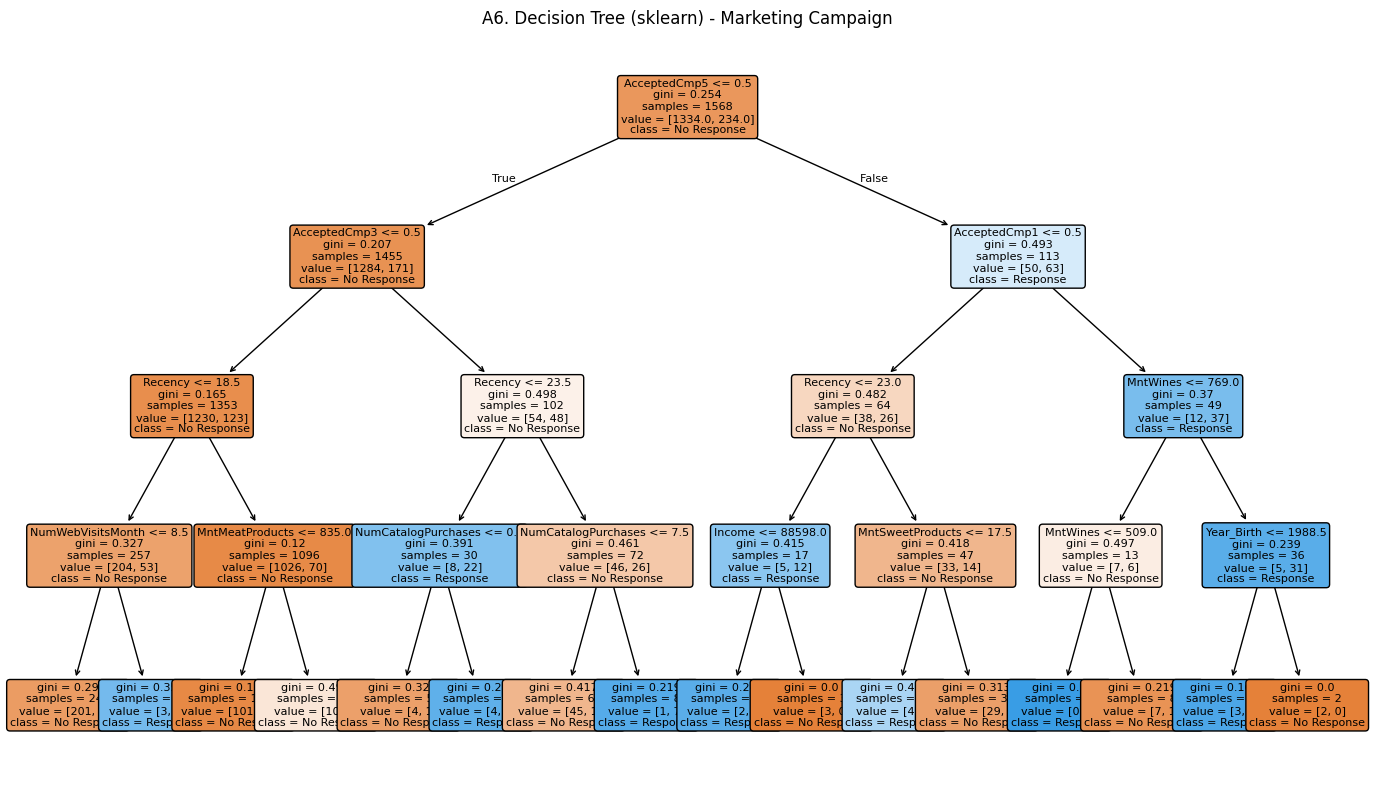

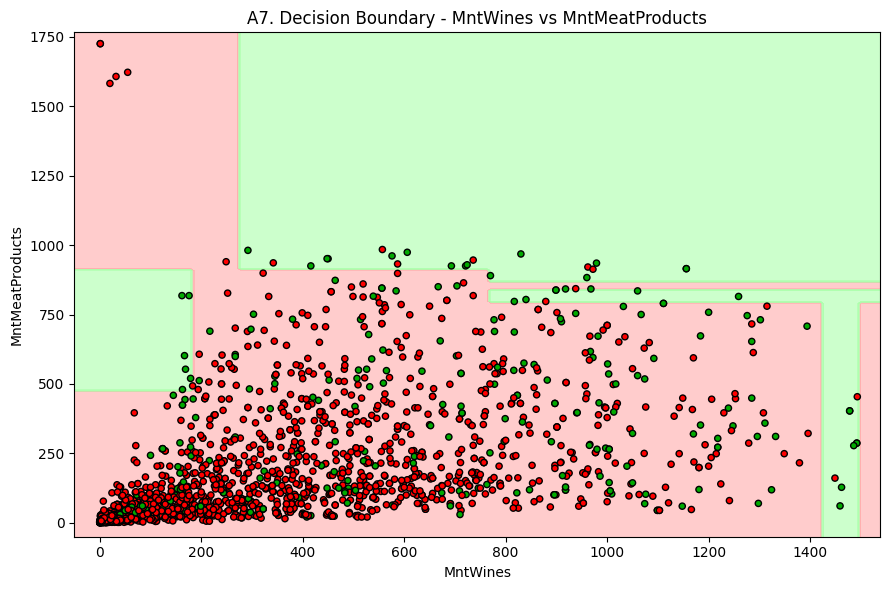


A8. GridSearchCV best params  : {'criterion': 'entropy', 'max_depth': 6, 'min_samples_split': 5}
    Best CV accuracy            : 0.8661
    Test accuracy (best model)  : 0.8795
A8. RandomizedSearchCV best params : {'criterion': 'entropy', 'max_depth': 6, 'min_samples_split': 2}
    Best CV accuracy               : 0.8629


In [3]:
# ============================================================
# 23CSE301 - Lab Session 07
# Decision Tree from Scratch using Entropy, Gini, Information Gain
# Dataset: marketing_campaign
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from matplotlib.colors import ListedColormap
from scipy.stats import randint


# ------------------------------------------------------------
# 0. Load & prepare the dataset
# ------------------------------------------------------------
def load_marketing_data(path, sheet_name="marketing_campaign"):
    """
    Load the marketing_campaign sheet, drop irrelevant columns,
    encode categorical features, handle missing values, and return
    X (numeric feature matrix), y (target), and feature names.
    """
    df = pd.read_excel(path, sheet_name=sheet_name)

    # 1. Drop irrelevant / constant columns
    drop_cols = ["ID", "Z_CostContact", "Z_Revenue", "Dt_Customer"]
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    # 2. Separate target
    y = df["Response"].astype(int).values
    X_df = df.drop(columns=["Response"]).copy()

    # 3. Encode categorical columns robustly
    for col in X_df.columns:
        if X_df[col].dtype == "object" or str(X_df[col].dtype) == "category":
            X_df[col] = X_df[col].astype(str).fillna("missing")
            X_df[col] = LabelEncoder().fit_transform(X_df[col])

    # 4. Force numeric dtype
    X_df = X_df.apply(pd.to_numeric, errors="coerce")

    # 5. Fill missing values with median, then 0 as a safety net
    X_df = X_df.fillna(X_df.median(numeric_only=True))
    X_df = X_df.fillna(0)

    return X_df.values.astype(float), y, list(X_df.columns)


# ------------------------------------------------------------
# A1. Entropy
# ------------------------------------------------------------
def entropy(y):
    """
    Shannon entropy H = -sum(p_i * log2(p_i)).
    """
    if len(y) == 0:
        return 0.0
    counts = np.bincount(np.asarray(y, dtype=int))
    probs = counts[counts > 0] / len(y)
    return float(-np.sum(probs * np.log2(probs)))


# ------------------------------------------------------------
# A1 (cont). Equal-width binning for continuous outcomes
# ------------------------------------------------------------
def equal_width_binning(series, n_bins=4):
    """
    Convert a continuous numeric series into n_bins equal-width
    categorical bins. Returns a pandas Series of bin indices.
    """
    s = pd.Series(series).reset_index(drop=True)
    lo, hi = s.min(), s.max()
    if hi == lo:
        return pd.Series(np.zeros(len(s), dtype=int))
    width = (hi - lo) / n_bins
    bins = [lo + i * width for i in range(n_bins + 1)]
    bins[-1] += 1e-9
    binned = pd.cut(s, bins=bins, labels=False, include_lowest=True)
    return binned.astype(int)


# ------------------------------------------------------------
# A2. Gini index
# ------------------------------------------------------------
def gini_index(y):
    """
    Gini = 1 - sum(p_j^2).
    """
    if len(y) == 0:
        return 0.0
    counts = np.bincount(np.asarray(y, dtype=int))
    probs = counts[counts > 0] / len(y)
    return float(1.0 - np.sum(probs ** 2))


# ------------------------------------------------------------
# A4. General binning utility (width or frequency)
# ------------------------------------------------------------
def bin_feature(series, n_bins=4, binning_type="width"):
    """
    Convert a continuous feature into categorical bins.
    binning_type: 'width' (equal-width) or 'frequency' (equal-frequency).
    Defaults emulate Python function 'overloading' via default args.
    """
    if n_bins is None:
        n_bins = 4
    s = pd.Series(series).reset_index(drop=True)
    if binning_type == "width":
        return equal_width_binning(s, n_bins)
    elif binning_type == "frequency":
        return pd.qcut(s, q=n_bins, labels=False,
                       duplicates="drop").astype(int)
    else:
        raise ValueError("binning_type must be 'width' or 'frequency'")


# ------------------------------------------------------------
# A3. Information Gain & best root feature
# ------------------------------------------------------------
def information_gain(parent_y, left_y, right_y):
    """
    IG = H(parent) - weighted average of H(children).
    """
    n = len(parent_y)
    if n == 0:
        return 0.0
    w_l = len(left_y) / n
    w_r = len(right_y) / n
    return entropy(parent_y) - (w_l * entropy(left_y) + w_r * entropy(right_y))


def find_best_split(X, y, binning_type="width", n_bins=4, bin_edges=None):
    """
    Scan all features and their binned unique values to find the split
    that maximises information gain.

    If `bin_edges` is provided (dict: feature_idx -> np.array of edges),
    those edges are used instead of re-learning them from `X`. This
    guarantees training/prediction consistency inside MyDecisionTree.

    Returns (best_feature_index, best_threshold, best_gain).
    """
    best_feature, best_threshold, best_gain = None, None, -np.inf

    for f in range(X.shape[1]):
        col = X[:, f]

        if bin_edges is not None and f in bin_edges:
            edges = bin_edges[f]
            if edges is None:
                col_binned = np.zeros(len(col), dtype=int)
            else:
                idx = np.digitize(col, edges[1:-1])
                col_binned = np.clip(idx, 0, n_bins - 1)
        else:
            col_binned = bin_feature(
                col, n_bins=n_bins, binning_type=binning_type
            ).values

        for val in np.unique(col_binned):
            left_mask = col_binned == val
            right_mask = ~left_mask
            if left_mask.sum() == 0 or right_mask.sum() == 0:
                continue
            gain = information_gain(y, y[left_mask], y[right_mask])
            if gain > best_gain:
                best_gain, best_feature, best_threshold = gain, f, val

    return best_feature, best_threshold, best_gain


# ------------------------------------------------------------
# A5. Decision Tree from scratch (FIXED binning consistency)
# ------------------------------------------------------------
class DecisionTreeNode:
    """A single node in the decision tree."""
    def __init__(self, feature=None, threshold=None,
                 left=None, right=None, value=None):
        self.feature = feature        # index of feature used for split
        self.threshold = threshold    # binned value -> left branch
        self.left = left              # DecisionTreeNode
        self.right = right            # DecisionTreeNode
        self.value = value            # class label if leaf


class MyDecisionTree:
    """
    CART-style decision tree classifier using Information Gain.

    Bin edges for each feature are learned ONCE during fit() and stored
    in self.bin_edges. Both tree construction and prediction reuse the
    SAME edges, guaranteeing consistent binning between train and test.
    """

    def __init__(self, max_depth=5, min_samples_split=2,
                 binning_type="width", n_bins=4):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.binning_type = binning_type
        self.n_bins = n_bins
        self.root = None
        self.bin_edges = {}    # feature_idx -> np.array of edges (or None)

    # ---------------- Binning helpers ----------------
    def _learn_bin_edges(self, X):
        """Compute bin edges for every feature from the training data."""
        self.bin_edges = {}
        for f in range(X.shape[1]):
            col = X[:, f]
            lo, hi = float(col.min()), float(col.max())

            if hi == lo:
                self.bin_edges[f] = None
                continue

            if self.binning_type == "width":
                width = (hi - lo) / self.n_bins
                edges = np.array([lo + i * width
                                  for i in range(self.n_bins + 1)])
                edges[-1] += 1e-9
            elif self.binning_type == "frequency":
                qs = np.linspace(0, 1, self.n_bins + 1)
                edges = np.unique(np.quantile(col, qs))
                if len(edges) < 2:
                    edges = np.array([lo, hi + 1e-9])
                edges[-1] += 1e-9
            else:
                raise ValueError("binning_type must be 'width' or 'frequency'")

            self.bin_edges[f] = edges

    def _bin_value(self, f, value):
        """Map a single value of feature f into its bin index."""
        edges = self.bin_edges.get(f)
        if edges is None:
            return 0
        idx = int(np.digitize(value, edges[1:-1]))
        return int(np.clip(idx, 0, self.n_bins - 1))

    def _bin_column(self, f, col):
        """Vectorised binning of a whole column using stored edges."""
        return np.array([self._bin_value(f, v) for v in col], dtype=int)

    # ---------------- Tree building ----------------
    def _build(self, X, y, depth):
        n_samples, _ = X.shape
        n_labels = len(np.unique(y))

        if (depth >= self.max_depth
                or n_labels == 1
                or n_samples < self.min_samples_split):
            leaf = Counter(y).most_common(1)[0][0]
            return DecisionTreeNode(value=leaf)

        feat, thr, gain = find_best_split(
            X, y,
            binning_type=self.binning_type,
            n_bins=self.n_bins,
            bin_edges=self.bin_edges,
        )

        if feat is None or gain <= 0:
            leaf = Counter(y).most_common(1)[0][0]
            return DecisionTreeNode(value=leaf)

        col_binned = self._bin_column(feat, X[:, feat])
        left_mask = col_binned == thr
        right_mask = ~left_mask

        left = self._build(X[left_mask], y[left_mask], depth + 1)
        right = self._build(X[right_mask], y[right_mask], depth + 1)
        return DecisionTreeNode(feature=feat, threshold=thr,
                                left=left, right=right)

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self._learn_bin_edges(X)     # learn edges ONCE
        self.root = self._build(X, y, 0)
        return self

    # ---------------- Prediction ----------------
    def _predict_one(self, x, node):
        if node.value is not None:
            return node.value
        binned_val = self._bin_value(node.feature, x[node.feature])
        if binned_val == node.threshold:
            return self._predict_one(x, node.left)
        return self._predict_one(x, node.right)

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return np.array([self._predict_one(x, self.root) for x in X])


# ------------------------------------------------------------
# A6 helper. Pretty-print the custom decision tree
# ------------------------------------------------------------
def print_tree(node, feature_names, depth=0, prefix="ROOT"):
    """
    Recursively print the structure of MyDecisionTree.
    Call from __main__ only (no prints inside model classes).
    """
    indent = "   " * depth
    if node.value is not None:
        print(f"{indent}[{prefix}] -> LEAF (class = {node.value})")
        return
    print(f"{indent}[{prefix}] if {feature_names[node.feature]} "
          f"in bin {node.threshold}:")
    print_tree(node.left, feature_names, depth + 1, "LEFT ")
    print_tree(node.right, feature_names, depth + 1, "RIGHT")


# ============================================================
# MAIN PROGRAM
# ============================================================
if __name__ == "__main__":

    PATH = r"D:\C drive files\Downloads\Lab Session Data (1) (1).xlsx"

    print("Using file:", PATH)
    print("Exists?   :", os.path.exists(PATH))
    print("-" * 60)

    if not os.path.exists(PATH):
        raise FileNotFoundError(
            "Excel file not found at the given path. "
            "Check the folder or file name."
        )

    # ---------- Load dataset ----------
    X, y, feature_names = load_marketing_data(PATH, "marketing_campaign")
    print("Dataset loaded: X =", X.shape, "| y =", y.shape)
    print("Feature names:", feature_names)
    print("-" * 60)

    # ---------- A1: Entropy ----------
    print("A1. Entropy of full dataset                : {:.4f}"
          .format(entropy(y)))

    income_series = pd.read_excel(PATH, sheet_name="marketing_campaign")["Income"]
    income_series = income_series.fillna(income_series.median())
    income_binned = equal_width_binning(income_series, 4)
    print("A1. Entropy after 4-bin equal-width binning: {:.4f}"
          .format(entropy(income_binned.values)))

    # ---------- A2: Gini ----------
    print("A2. Gini index of full dataset             : {:.4f}"
          .format(gini_index(y)))
    print("A2. Gini after binning                     : {:.4f}"
          .format(gini_index(income_binned.values)))

    # ---------- A3: Root feature via Information Gain ----------
    feat, thr, gain = find_best_split(X, y, binning_type="width", n_bins=4)
    print("\nA3. Best root feature : {} ({})"
          .format(feat, feature_names[feat]))
    print("    Best binned threshold : {}, Information Gain : {:.4f}"
          .format(thr, gain))

    # ---------- A4: Binning with parameters ----------
    sample_col = X[:, 0]
    print("\nA4. Equal-width binning (4 bins, first 10):")
    print(bin_feature(sample_col, n_bins=4, binning_type="width").values[:10])
    print("A4. Equal-frequency binning (4 bins, first 10):")
    print(bin_feature(sample_col, n_bins=4,
                      binning_type="frequency").values[:10])

    # ---------- A5: Build custom Decision Tree ----------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y)

    my_tree = MyDecisionTree(max_depth=4, min_samples_split=2,
                             binning_type="width", n_bins=4)
    my_tree.fit(X_train, y_train)
    y_pred = my_tree.predict(X_test)

    print("\nA5. Custom Decision Tree Test Accuracy  : {:.4f}"
          .format(accuracy_score(y_test, y_pred)))

    # Sanity check: both classes should appear in predictions
    print("    Prediction distribution (class: count) :",
          dict(zip(*np.unique(y_pred, return_counts=True))))
    print("    True label distribution                :",
          dict(zip(*np.unique(y_test, return_counts=True))))

    # Print the custom tree structure (satisfies A6 spirit)
    print("\nA6. Custom Decision Tree Structure:")
    print_tree(my_tree.root, feature_names)

    # ---------- A6: Visualise using sklearn's plot_tree ----------
    sklearn_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
    sklearn_tree.fit(X_train, y_train)

    plt.figure(figsize=(14, 8))
    plot_tree(sklearn_tree,
              feature_names=feature_names,
              class_names=["No Response", "Response"],
              filled=True, rounded=True, fontsize=8)
    plt.title("A6. Decision Tree (sklearn) - Marketing Campaign")
    plt.tight_layout()
    plt.show()

    # ---------- A7: Decision boundary with 2 features ----------
    f1, f2 = "MntWines", "MntMeatProducts"
    idx1 = feature_names.index(f1)
    idx2 = feature_names.index(f2)

    X2 = X[:, [idx1, idx2]]
    X2_train, X2_test, y2_train, y2_test = train_test_split(
        X2, y, test_size=0.3, random_state=42, stratify=y)

    dt2 = DecisionTreeClassifier(max_depth=4, random_state=42)
    dt2.fit(X2_train, y2_train)

    x_min, x_max = X2[:, 0].min() - 50, X2[:, 0].max() + 50
    y_min, y_max = X2[:, 1].min() - 50, X2[:, 1].max() + 50

    # Finer grid for a smoother boundary
    step = max((x_max - x_min) / 200, (y_max - y_min) / 200)
    xx, yy = np.meshgrid(np.arange(x_min, x_max, step),
                         np.arange(y_min, y_max, step))
    Z = dt2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    cmap_bg = ListedColormap(["#FFAAAA", "#AAFFAA"])
    cmap_pt = ListedColormap(["#FF0000", "#00AA00"])

    plt.figure(figsize=(9, 6))
    plt.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.6)
    plt.scatter(X2[:, 0], X2[:, 1], c=y,
                cmap=cmap_pt, edgecolor="k", s=20)
    plt.xlabel(f1)
    plt.ylabel(f2)
    plt.title("A7. Decision Boundary - {} vs {}".format(f1, f2))
    plt.tight_layout()
    plt.show()

    # ---------- A8: Hyper-parameter tuning ----------
    param_grid = {
        "max_depth": [2, 3, 4, 5, 6, None],
        "min_samples_split": [2, 3, 5, 10],
        "criterion": ["gini", "entropy"]
    }
    grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                        param_grid, cv=5, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train, y_train)
    print("\nA8. GridSearchCV best params  :", grid.best_params_)
    print("    Best CV accuracy            : {:.4f}".format(grid.best_score_))
    print("    Test accuracy (best model)  : {:.4f}"
          .format(accuracy_score(y_test,
                                 grid.best_estimator_.predict(X_test))))

    rand_dist = {
        "max_depth": randint(2, 12),
        "min_samples_split": randint(2, 15),
        "criterion": ["gini", "entropy"]
    }
    rnd = RandomizedSearchCV(DecisionTreeClassifier(random_state=42),
                             rand_dist, n_iter=20, cv=5,
                             scoring="accuracy", random_state=42, n_jobs=-1)
    rnd.fit(X_train, y_train)
    print("A8. RandomizedSearchCV best params :", rnd.best_params_)
    print("    Best CV accuracy               : {:.4f}".format(rnd.best_score_))